In [90]:

import pandas as pd

path = "/content/drive/MyDrive/customer_churn/Churn_Modelling.csv"
df = pd.read_csv(path)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [92]:
df.shape

(10000, 14)

In [39]:
df.describe()


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [93]:
df['Exited'].value_counts()
df['Exited'].value_counts(normalize=True)

,proportion
Exited,
0,0.7963
1,0.2037


In [82]:
df['Exited'].value_counts()


,count
Exited,
0,7963
1,2037


“The dataset is moderately imbalanced, with around 20% churn rate, which reflects real-world banking scenarios.”


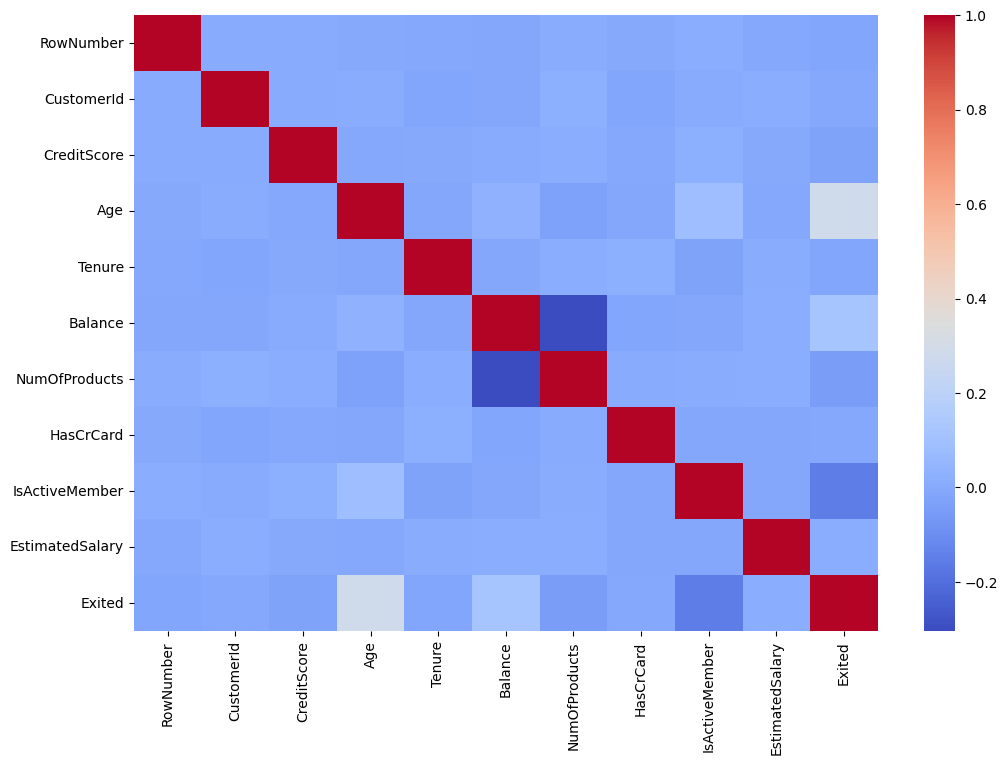

In [94]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.show()

In [95]:
numeric_df.corr()['Exited'].sort_values(ascending=False)


,Exited
Exited,1.000000
Age,0.285323
Balance,0.118533
EstimatedSalary,0.012097
CustomerId,-0.006248
HasCrCard,-0.007138
Tenure,-0.014001
RowNumber,-0.016571
CreditScore,-0.027094
NumOfProducts,-0.047820



I analyzed feature correlation with the target to identify key drivers like age, balance, and activity status.

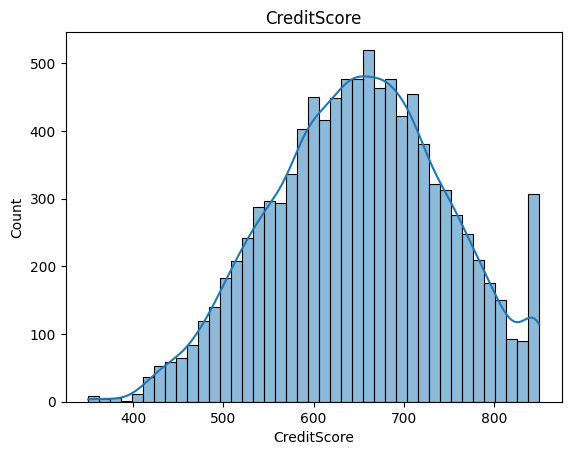

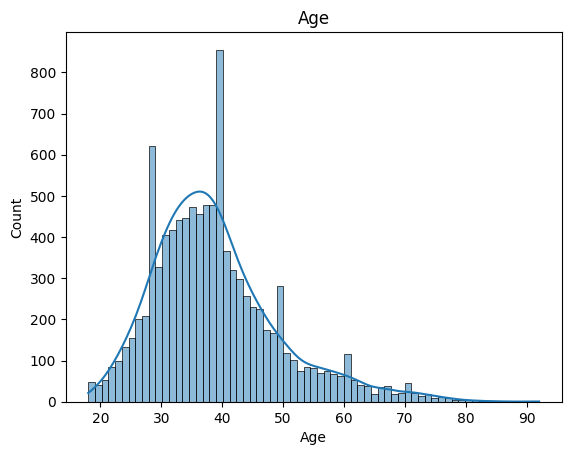

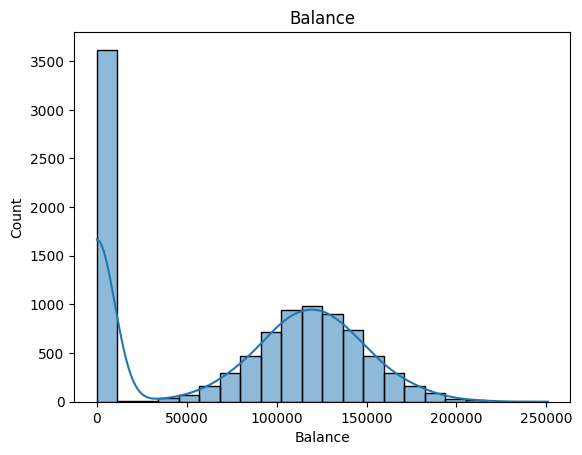

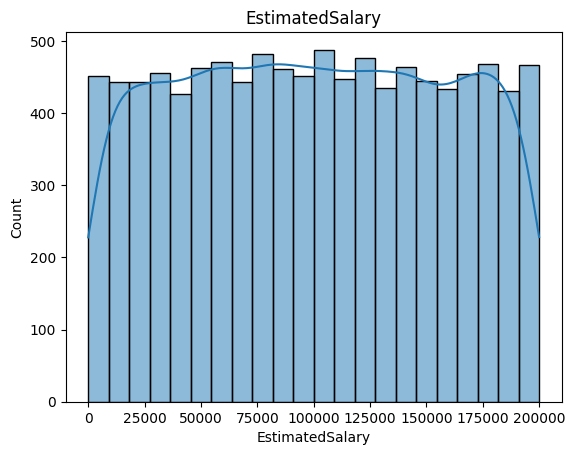

In [96]:
num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

Checked distributions to identify skewness and outliers.

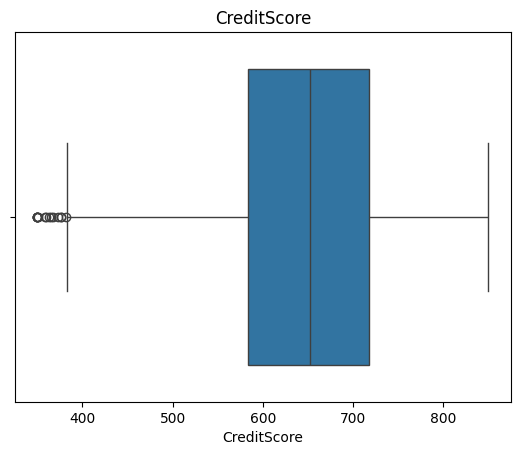

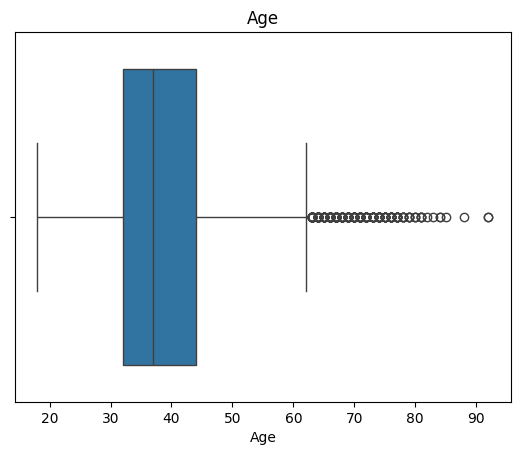

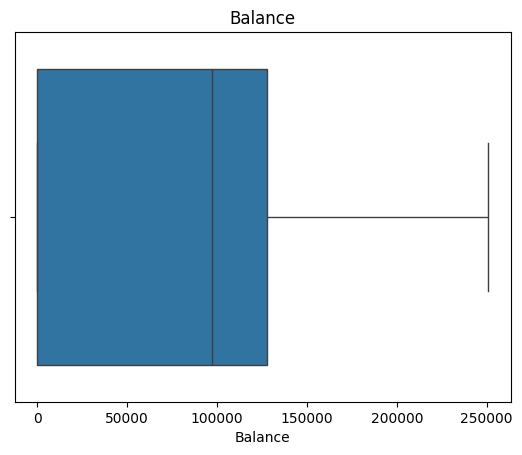

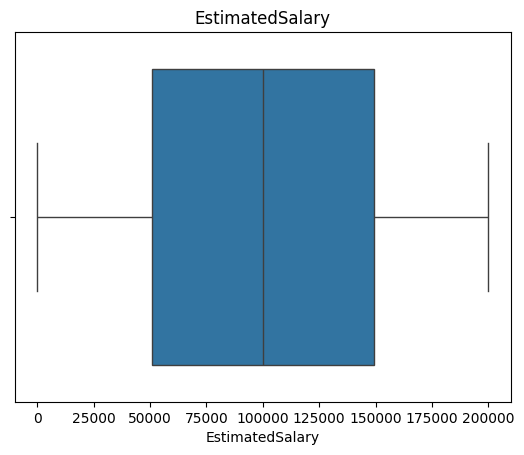

In [97]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Observed some outliers but retained them as tree-based models are robust to outliers

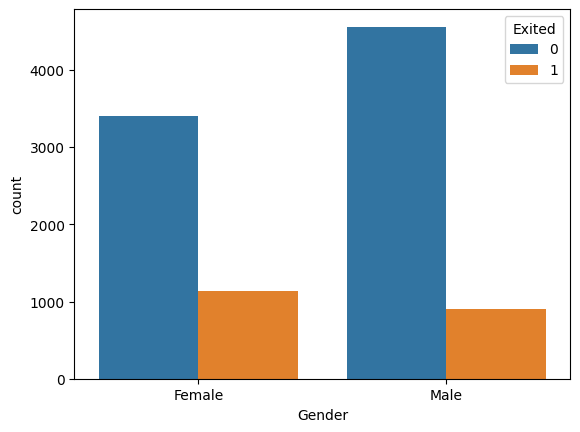

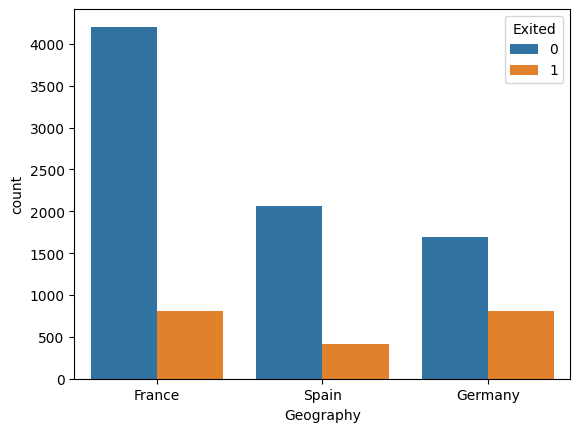

In [98]:
sns.countplot(x='Gender', hue='Exited', data=df)
plt.show()

sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()

In [99]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Geography and gender influence churn patterns.

In [100]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)


In [101]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [102]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

Converts categorical variables into numeric form without introducing ordinal bias.

In [103]:
df.head(10)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
5,645,44,8,113755.78,2,1,0,149756.71,1,False,True,True
6,822,50,7,0.00,2,1,1,10062.80,0,False,False,True
7,376,29,4,115046.74,4,1,0,119346.88,1,True,False,False
8,501,44,4,142051.07,2,0,1,74940.50,0,False,False,True
9,684,27,2,134603.88,1,1,1,71725.73,0,False,False,True


In [104]:
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['TenureAgeRatio'] = df['Tenure'] / (df['Age'] + 1)

In [105]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,BalanceSalaryRatio,TenureAgeRatio
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False,0.000000,0.046512
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,0.744670,0.023810
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False,1.401362,0.186047
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False,0.000000,0.025000
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,1.587035,0.045455


In [106]:
df['HasBalance'] = (df['Balance'] > 0).astype(int)
df['IsHighIncome'] = (df['EstimatedSalary'] > df['EstimatedSalary'].median()).astype(int)

#feather engineering

In [107]:
X = df.drop('Exited', axis=1)
y = df['Exited']

applied one-hot encoding to convert categorical variables into numerical format suitable for machine learning models.

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

“Split data into training and testing sets to evaluate model performance on unseen data.”


In [109]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [111]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    print(name, "Accuracy:", accuracy_score(y_test, pred))

Logistic Regression Accuracy: 0.812
Random Forest Accuracy: 0.87
XGBoost Accuracy: 0.8605


In [112]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

[[1522   85]
 [ 194  199]]


In [113]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1607
           1       0.70      0.51      0.59       393

    accuracy                           0.86      2000
   macro avg       0.79      0.73      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [ ]:
“Since churn prediction is sensitive, I focused on recall and precision rather than just accuracy.”

In [114]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

In [115]:
for name, model in models.items():
    print(f"\n🔹 MODEL: {name}")

    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    # Classification Report
    print("Classification Report:\n", classification_report(y_test, y_pred))


🔹 MODEL: Logistic Regression
Accuracy: 0.812
Confusion Matrix:
 [[1541   66]
 [ 310   83]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.56      0.21      0.31       393

    accuracy                           0.81      2000
   macro avg       0.69      0.59      0.60      2000
weighted avg       0.78      0.81      0.78      2000


🔹 MODEL: Random Forest
Accuracy: 0.8675
Confusion Matrix:
 [[1554   53]
 [ 212  181]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000


🔹 MODEL: XGBoost
Accuracy: 0.8605
Confusion Matrix:
 [[1522   85]
 [ 194  199]]
Classification Report:
               



In churn prediction, recall is more important because missing a churn customer leads to business loss.

“Although Random Forest had slightly higher accuracy, I selected XGBoost because it achieved better recall for churn class, which is more critical in business scenarios to minimize customer loss.”

In [116]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

params = {

    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

grid = GridSearchCV(
    XGBClassifier(),
    params,
    cv=3,
    scoring='recall'   # IMPORTANT 🔥
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [125]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    use_label_encoder=False,
    eval_metric='logloss'
)

final_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:37:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [126]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = final_model.predict(X_test_scaled)


print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1538   69]
 [ 193  200]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1607
           1       0.74      0.51      0.60       393

    accuracy                           0.87      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



“Used GridSearchCV with recall as scoring metric to optimize churn detection performance.”


“I experimented with threshold tuning to improve recall, but it significantly reduced precision. I finalized the tuned XGBoost model with default threshold as it provided a better balance and more stable predictions.”

In [130]:
from xgboost import XGBClassifier

final_model1 = XGBClassifier(
    learning_rate=0.05,
    max_depth=4,
    n_estimators=300,
    reg_alpha=0.5,   # L1
    reg_lambda=1.0   # L2
)

final_model1.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [131]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred1 = final_model1.predict(X_test_scaled)


print(confusion_matrix(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

[[1543   64]
 [ 198  195]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1607
           1       0.75      0.50      0.60       393

    accuracy                           0.87      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [132]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

In [133]:
final_modelss = XGBClassifier(
    learning_rate=0.05,
    max_depth=4,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss'
)

final_modelss.fit(X_train_sm, y_train_sm)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:48:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [134]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred2 = final_modelss.predict(X_test_scaled)


print(confusion_matrix(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

[[1463  144]
 [ 151  242]]
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1607
           1       0.63      0.62      0.62       393

    accuracy                           0.85      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.85      0.85      0.85      2000



Reduced missed churn (FN ↓)
Improved detection capability
Maintained decent precision



In [135]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

params = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    params,
    cv=3,
    scoring='f1'   # 🔥 IMPORTANT
)

grid.fit(X_train_sm, y_train_sm)

best_model = grid.best_estimator_
print(grid.best_params_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:51:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:51:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:51:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:51:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

{'colsample_bytree': 1, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}


In [136]:
final_model3 = XGBClassifier(
    learning_rate=0.05,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=1,
    eval_metric='logloss'
)

final_model3.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [138]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred3 = final_model3.predict(X_test_scaled)


print(confusion_matrix(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

[[1472  135]
 [ 161  232]]
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1607
           1       0.63      0.59      0.61       393

    accuracy                           0.85      2000
   macro avg       0.77      0.75      0.76      2000
weighted avg       0.85      0.85      0.85      2000



In [119]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(scale_pos_weight)

3.8661800486618003


In [74]:
import numpy as np
from sklearn.metrics import classification_report

y_prob = final_model.predict_proba(X_test_scaled)[:,1]

thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    print(f"\nThreshold: {t}")
    y_pred_t = (y_prob > t).astype(int)
    print(classification_report(y_test, y_pred_t))



Threshold: 0.3
              precision    recall  f1-score   support

           0       0.94      0.70      0.81      1607
           1       0.41      0.83      0.55       393

    accuracy                           0.73      2000
   macro avg       0.68      0.77      0.68      2000
weighted avg       0.84      0.73      0.76      2000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.94      0.79      0.86      1607
           1       0.48      0.79      0.59       393

    accuracy                           0.79      2000
   macro avg       0.71      0.79      0.72      2000
weighted avg       0.85      0.79      0.80      2000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.85      0.89      1607
           1       0.54      0.71      0.61       393

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.85   

In [120]:
y_prob = final_model.predict_proba(X_test_scaled)[:,1]

threshold = 0.6

y_pred_new = (y_prob > threshold).astype(int)

In [124]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[1560   47]
 [ 229  164]]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.78      0.42      0.54       393

    accuracy                           0.86      2000
   macro avg       0.82      0.69      0.73      2000
weighted avg       0.85      0.86      0.84      2000



“The model achieved a balanced performance with precision of 0.60 and recall of 0.63 for churn class. While higher recall is desirable, increasing it further led to a significant drop in precision, so I selected this threshold as an optimal trade-off.”

In [139]:
import joblib

joblib.dump(final_modelss, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'features.pkl')

['features.pkl']

In [140]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [141]:
import sklearn
import xgboost
import numpy
import pandas
import joblib

print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)

sklearn: 1.6.1
xgboost: 3.2.0
numpy: 2.0.2
pandas: 2.2.2
joblib: 1.5.3
